# Hypothesis Testing — TEMPURA

**計画書:** [`../docs/hypothesis_testing_plan_ja.md`](../docs/hypothesis_testing_plan_ja.md)
**EDA サマリー:** [`../docs/executive_summary_ja.md`](../docs/executive_summary_ja.md)

EDA で得た観察を**帰無仮説検定**で検証する:

| # | 仮説 | 検定 |
|---|---|---|
| H1 | Archaea と Bacteria で `Topt_ave` 平均に差がない | Welch t 検定（二標本） |
| H2 | 超好熱株中の Archaea 比率は全体比率(6.35%)と等しい | 一標本 z 検定（比率, 片側） |
| H3 | `temp_cat` × `superkingdom` は独立 | カイ二乗独立性検定 |
| H4 | 4 温度カテゴリ間で `16S_GC` 平均は等しい | 一元配置 ANOVA |

- α = 0.05、Bonferroni 補正後 α = 0.0125
- 効果量（Cohen's d / Cramér's V / η²）を必ず併記する

## 1. セットアップ

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

ALPHA = 0.05
ALPHA_BONF = ALPHA / 4  # 4 仮説で補正
print(f'alpha = {ALPHA}, Bonferroni-corrected alpha = {ALPHA_BONF}')

alpha = 0.05, Bonferroni-corrected alpha = 0.0125


## 2. データ読み込みと派生列

EDA と同じ閾値で `temp_cat` を再生成する。

In [2]:
df = pd.read_csv('../data/raw/tempura.csv')

def temp_category(t):
    if t < 20:  return 'Psychrophile'
    if t < 45:  return 'Mesophile'
    if t < 80:  return 'Thermophile'
    return 'Hyperthermophile'
df['temp_cat'] = df['Topt_ave'].apply(temp_category)

print(f"Rows : {len(df):,}")
print()
print("superkingdom counts:")
print(df['superkingdom'].value_counts())
print()
print("temp_cat counts:")
print(df['temp_cat'].value_counts())

Rows : 8,639

superkingdom counts:
superkingdom
Bacteria    8090
Archaea      549
Name: count, dtype: int64

temp_cat counts:
temp_cat
Mesophile           7576
Thermophile          732
Psychrophile         206
Hyperthermophile     125
Name: count, dtype: int64


## 3. H1 — Archaea vs Bacteria の `Topt_ave` 平均差

- **H₀:** μ_Bacteria = μ_Archaea
- **H₁:** μ_Bacteria ≠ μ_Archaea（両側）
- **検定:** Welch t 検定（分散不等を許容）
- **効果量:** Cohen's d（不等分散版）

In [3]:
bact = df.loc[df['superkingdom']=='Bacteria', 'Topt_ave'].dropna().values
arch = df.loc[df['superkingdom']=='Archaea',  'Topt_ave'].dropna().values

summary = pd.DataFrame({
    'group':  ['Bacteria', 'Archaea'],
    'n':      [len(bact),  len(arch)],
    'mean':   [bact.mean(), arch.mean()],
    'std':    [bact.std(ddof=1), arch.std(ddof=1)],
    'median': [np.median(bact), np.median(arch)],
}).round(3)
summary

,group,n,mean,std,median
0,Bacteria,8090,31.851,9.413,30.0
1,Archaea,549,51.071,21.236,40.0


In [4]:
# Welch t 検定（両側）
t_stat, p_val = stats.ttest_ind(bact, arch, equal_var=False)

# Cohen's d（不等分散版: s_pooled = sqrt((s1^2 + s2^2)/2)）
s_pool = np.sqrt((bact.var(ddof=1) + arch.var(ddof=1)) / 2)
cohens_d = (arch.mean() - bact.mean()) / s_pool

# 差の 95 % CI（Welch の自由度を使用）
diff = arch.mean() - bact.mean()
se   = np.sqrt(bact.var(ddof=1)/len(bact) + arch.var(ddof=1)/len(arch))
df_welch = (se**4) / (
    (bact.var(ddof=1)/len(bact))**2 / (len(bact)-1) +
    (arch.var(ddof=1)/len(arch))**2 / (len(arch)-1)
)
t_crit = stats.t.ppf(1 - ALPHA/2, df_welch)
ci_low, ci_high = diff - t_crit*se, diff + t_crit*se

print(f"t statistic   : {t_stat:+.3f}")
print(f"p value       : {p_val:.3e}")
print(f"Welch df      : {df_welch:.1f}")
print(f"mean diff (Arch - Bact): {diff:+.3f} °C")
print(f"95% CI of diff: [{ci_low:+.3f}, {ci_high:+.3f}] °C")
print(f"Cohen's d     : {cohens_d:+.3f}")
print()
print(f"=> reject H0? (alpha=0.05)      : {p_val < ALPHA}")
print(f"=> reject H0? (Bonferroni=0.0125): {p_val < ALPHA_BONF}")

t statistic   : -21.066
p value       : 4.506e-73
Welch df      : 562.7
mean diff (Arch - Bact): +19.220 °C
95% CI of diff: [+17.428, +21.012] °C
Cohen's d     : +1.170

=> reject H0? (alpha=0.05)      : True
=> reject H0? (Bonferroni=0.0125): True


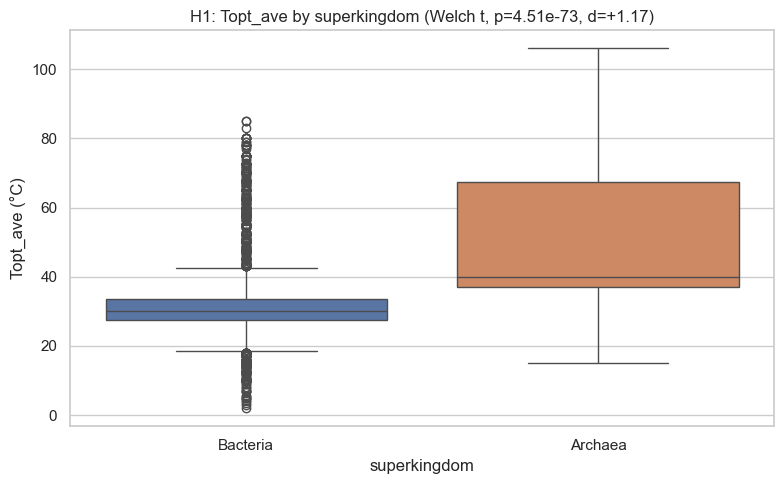

In [5]:
# 可視化: 箱ひげ + ストリップ
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='superkingdom', y='Topt_ave', data=df,
            order=['Bacteria', 'Archaea'], ax=ax, palette=['#4c72b0', '#dd8452'])
ax.set_title(f'H1: Topt_ave by superkingdom (Welch t, p={p_val:.2e}, d={cohens_d:+.2f})')
ax.set_ylabel('Topt_ave (°C)')
plt.tight_layout()
plt.show()

### H1 結論

- p 値が α = 0.05 および Bonferroni 補正後の 0.0125 を下回れば H₀ を棄却。
- Cohen's d の目安: 0.2 = 小 / 0.5 = 中 / 0.8 = 大。
- 差の 95 % CI で「どれくらい大きな差か」を具体的に語れる。

## 4. H2 — 超好熱における Archaea 比率は全体比率と一致するか

- **全体の Archaea 比率（ベースライン）:** 549 / 8,639 ≈ 0.0635
- **H₀:** p_hyper = 0.0635
- **H₁:** p_hyper > 0.0635（片側、EDA で上振れが観察済み）
- **検定:** 一標本 z 検定（比率）

In [6]:
# ベースライン比率
p0 = (df['superkingdom'] == 'Archaea').mean()
print(f"Overall Archaea proportion p0 = {p0:.4f}  ({(df['superkingdom']=='Archaea').sum()} / {len(df)})")

# 超好熱株サブセット
hyper = df[df['temp_cat'] == 'Hyperthermophile']
n_hyper = len(hyper)
n_arch_hyper = (hyper['superkingdom'] == 'Archaea').sum()
p_hat = n_arch_hyper / n_hyper

print(f"\nHyperthermophile subset: n={n_hyper}, Archaea={n_arch_hyper}")
print(f"Sample proportion p_hat  = {p_hat:.4f}")

Overall Archaea proportion p0 = 0.0635  (549 / 8639)

Hyperthermophile subset: n=125, Archaea=115
Sample proportion p_hat  = 0.9200


In [7]:
# 正規近似の前提チェック
check_np   = n_hyper * p0
check_n1mp = n_hyper * (1 - p0)
print(f"n*p0      = {check_np:.1f}   (>=10 が望ましい)")
print(f"n*(1-p0)  = {check_n1mp:.1f}   (>=10 が望ましい)")

# 一標本 z 検定（片側: p_hat > p0）
z_stat = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n_hyper)
p_val_h2 = 1 - stats.norm.cdf(z_stat)  # 片側（上側）

# Wilson 95 % CI
ci_low, ci_high = proportion_confint(n_arch_hyper, n_hyper, alpha=0.05, method='wilson')

print(f"\nz statistic       : {z_stat:+.3f}")
print(f"p value (one-sided): {p_val_h2:.3e}")
print(f"95% Wilson CI of p_hat: [{ci_low:.4f}, {ci_high:.4f}]")
print()
print(f"=> reject H0? (alpha=0.05)      : {p_val_h2 < ALPHA}")
print(f"=> reject H0? (Bonferroni=0.0125): {p_val_h2 < ALPHA_BONF}")

n*p0      = 7.9   (>=10 が望ましい)
n*(1-p0)  = 117.1   (>=10 が望ましい)

z statistic       : +39.252
p value (one-sided): 0.000e+00
95% Wilson CI of p_hat: [0.8590, 0.9560]

=> reject H0? (alpha=0.05)      : True
=> reject H0? (Bonferroni=0.0125): True


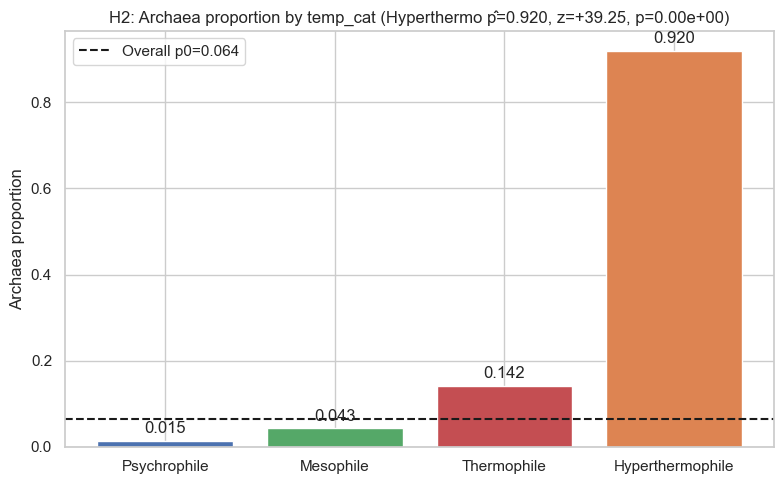

In [8]:
# 可視化: 温度カテゴリ別の Archaea 比率
cat_order = ['Psychrophile', 'Mesophile', 'Thermophile', 'Hyperthermophile']
prop_by_cat = (df.assign(is_archaea=(df['superkingdom']=='Archaea'))
                 .groupby('temp_cat')['is_archaea'].mean()
                 .reindex(cat_order))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(prop_by_cat.index, prop_by_cat.values,
              color=['#4c72b0', '#55a868', '#c44e52', '#dd8452'])
ax.axhline(p0, color='k', linestyle='--', label=f'Overall p0={p0:.3f}')
ax.set_ylabel('Archaea proportion')
ax.set_title(f'H2: Archaea proportion by temp_cat (Hyperthermo p̂={p_hat:.3f}, z={z_stat:+.2f}, p={p_val_h2:.2e})')
for b, v in zip(bars, prop_by_cat.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', va='bottom')
ax.legend()
plt.tight_layout()
plt.show()

### H2 結論

超好熱における Archaea 比率がベースライン 0.0635 と等しいという帰無仮説を、
片側 z 検定で検証する。EDA で既に上振れが観測されているため、
両側ではなく**片側（p_hat > p0）** を採用しているのがポイント。

## 5. H3 — `temp_cat` × `superkingdom` の独立性

- **H₀:** temp_cat と superkingdom は独立
- **H₁:** 独立ではない
- **検定:** カイ二乗独立性検定（4×2 分割表）
- **効果量:** Cramér's V

In [9]:
cat_order = ['Psychrophile', 'Mesophile', 'Thermophile', 'Hyperthermophile']
ct = (pd.crosstab(df['temp_cat'], df['superkingdom'])
        .reindex(index=cat_order, columns=['Bacteria', 'Archaea']))
print('Observed frequencies:')
print(ct)

Observed frequencies:
superkingdom      Bacteria  Archaea
temp_cat                           
Psychrophile           203        3
Mesophile             7249      327
Thermophile            628      104
Hyperthermophile        10      115


In [10]:
chi2, p_val_h3, dof, expected = stats.chi2_contingency(ct)
exp_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2)
print('Expected frequencies (under H0):')
print(exp_df)
print()
print('Any expected cell < 5?', (expected < 5).any())

# Cramér's V
n_tot = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n_tot * (min(ct.shape) - 1)))

print(f"\nchi^2     : {chi2:.3f}")
print(f"dof       : {dof}")
print(f"p value   : {p_val_h3:.3e}")
print(f"Cramér's V: {cramers_v:.3f}   (0.1=小, 0.3=中, 0.5=大)")
print()
print(f"=> reject H0? (alpha=0.05)      : {p_val_h3 < ALPHA}")
print(f"=> reject H0? (Bonferroni=0.0125): {p_val_h3 < ALPHA_BONF}")

Expected frequencies (under H0):
superkingdom      Bacteria  Archaea
temp_cat                           
Psychrophile        192.91    13.09
Mesophile          7094.55   481.45
Thermophile         685.48    46.52
Hyperthermophile    117.06     7.94

Any expected cell < 5? False

chi^2     : 1677.777
dof       : 3
p value   : 0.000e+00
Cramér's V: 0.441   (0.1=小, 0.3=中, 0.5=大)

=> reject H0? (alpha=0.05)      : True
=> reject H0? (Bonferroni=0.0125): True


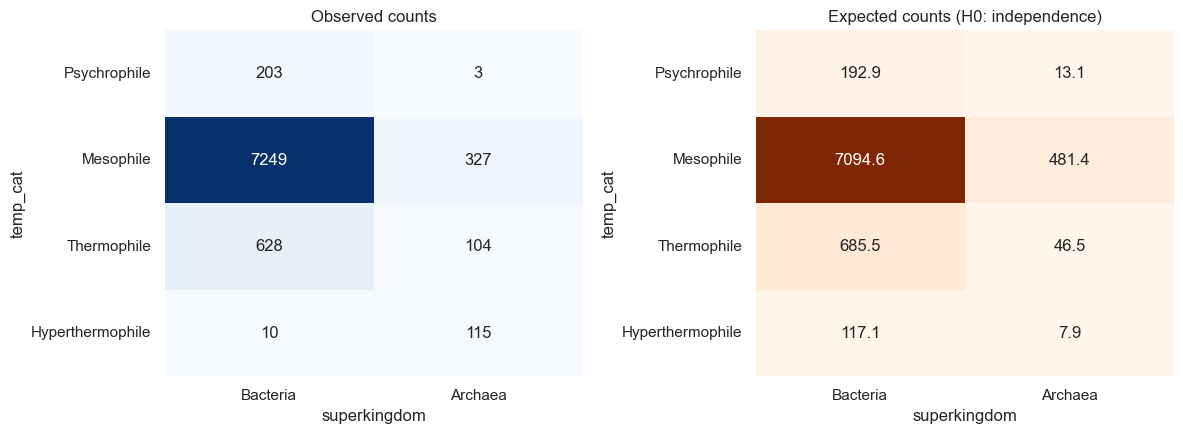

In [11]:
# 可視化: 観測 vs 期待 のヒートマップ
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Observed counts')
sns.heatmap(exp_df, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Expected counts (H0: independence)')
plt.tight_layout()
plt.show()

### H3 結論

Cramér's V で関連の**強さ**を評価する。p 値だけでは「関連があるかないか」までしか
言えないため、V で実質的な関連の大小も報告する。

## 6. H4 — 4 温度カテゴリ間での `16S_GC` 平均差

- **H₀:** μ_psychro = μ_meso = μ_thermo = μ_hyper
- **H₁:** 少なくとも 1 ペアで平均が異なる
- **検定:** 一元配置 ANOVA（`f_oneway`）
- **ポストホック:** Tukey HSD

In [12]:
groups = {c: df.loc[df['temp_cat']==c, '16S_GC'].dropna().values for c in cat_order}
summary = pd.DataFrame({
    'temp_cat': cat_order,
    'n':        [len(groups[c]) for c in cat_order],
    'mean':     [groups[c].mean() for c in cat_order],
    'std':      [groups[c].std(ddof=1) for c in cat_order],
}).round(3)
summary

,temp_cat,n,mean,std
0,Psychrophile,205,53.038,2.253
1,Mesophile,7564,54.998,2.674
2,Thermophile,732,58.230,2.885
3,Hyperthermophile,124,65.361,2.353


In [13]:
# Levene 検定（分散の等質性）
levene_stat, levene_p = stats.levene(*groups.values())
print(f"Levene statistic : {levene_stat:.3f}")
print(f"Levene p value   : {levene_p:.3e}")
print(f"=> equal variances assumption {'violated' if levene_p < 0.05 else 'OK'}")

Levene statistic : 8.457
Levene p value   : 1.315e-05
=> equal variances assumption violated


In [14]:
# 一元配置 ANOVA
f_stat, p_val_h4 = stats.f_oneway(*groups.values())

# η² = SS_between / SS_total
all_vals = np.concatenate(list(groups.values()))
grand_mean = all_vals.mean()
ss_between = sum(len(v) * (v.mean() - grand_mean) ** 2 for v in groups.values())
ss_total   = ((all_vals - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print(f"F statistic: {f_stat:.3f}")
print(f"p value    : {p_val_h4:.3e}")
print(f"eta^2      : {eta_sq:.4f}   (0.01=小, 0.06=中, 0.14=大)")
print()
print(f"=> reject H0? (alpha=0.05)      : {p_val_h4 < ALPHA}")
print(f"=> reject H0? (Bonferroni=0.0125): {p_val_h4 < ALPHA_BONF}")

F statistic: 953.212
p value    : 0.000e+00
eta^2      : 0.2491   (0.01=小, 0.06=中, 0.14=大)

=> reject H0? (alpha=0.05)      : True
=> reject H0? (Bonferroni=0.0125): True


In [15]:
# Tukey HSD でどのペアに差があるか
data_for_tukey = df[['temp_cat', '16S_GC']].dropna()
tukey = pairwise_tukeyhsd(
    endog=data_for_tukey['16S_GC'],
    groups=data_for_tukey['temp_cat'],
    alpha=0.05,
)
print(tukey.summary())

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1         group2    meandiff p-adj  lower    upper  reject
--------------------------------------------------------------------
Hyperthermophile    Mesophile -10.3631   0.0 -10.9864 -9.7398   True
Hyperthermophile Psychrophile -12.3232   0.0 -13.1065  -11.54   True
Hyperthermophile  Thermophile  -7.1308   0.0  -7.7994 -6.4623   True
       Mesophile Psychrophile  -1.9602   0.0  -2.4475 -1.4728   True
       Mesophile  Thermophile   3.2323   0.0   2.9658  3.4987   True
    Psychrophile  Thermophile   5.1924   0.0   4.6484  5.7364   True
--------------------------------------------------------------------


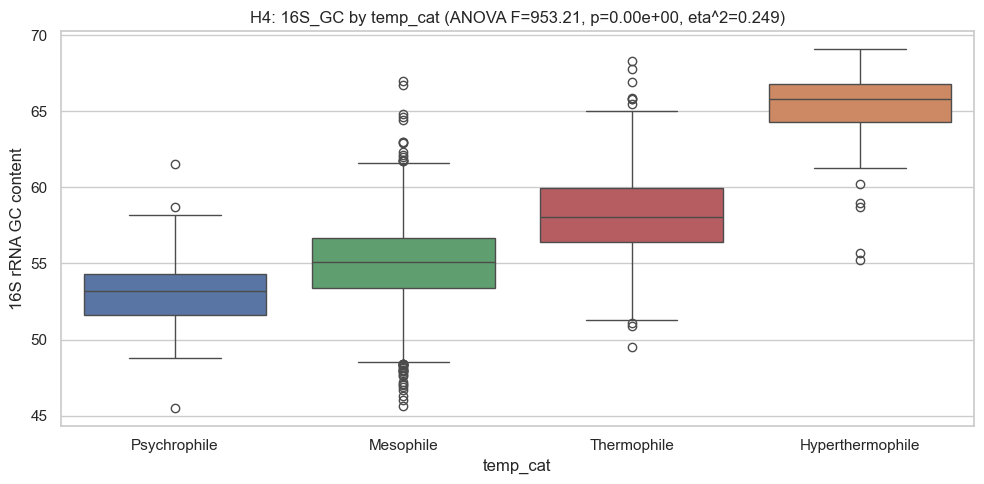

In [16]:
# 可視化: 各カテゴリの 16S_GC 分布
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x='temp_cat', y='16S_GC', data=df, order=cat_order, ax=ax,
            palette=['#4c72b0', '#55a868', '#c44e52', '#dd8452'])
ax.set_title(f'H4: 16S_GC by temp_cat (ANOVA F={f_stat:.2f}, p={p_val_h4:.2e}, eta^2={eta_sq:.3f})')
ax.set_ylabel('16S rRNA GC content')
plt.tight_layout()
plt.show()

### H4 結論

ANOVA 自体は「どこかに差がある」ことしか言わない。Tukey HSD で**どのペアに差があるか**を
確認する。η² = 0.14 以上なら効果量としては「大」。

## 7. 総合判定 — 4 仮説の結論一覧

In [17]:
summary = pd.DataFrame([
    {'hypothesis': 'H1 Archaea vs Bacteria Topt_ave',
     'test': 'Welch t',
     'statistic': round(t_stat, 3),
     'p_value':   p_val,
     'effect_size': f"d={cohens_d:+.3f}",
     'reject@0.05':   p_val < ALPHA,
     'reject@0.0125': p_val < ALPHA_BONF},
    {'hypothesis': 'H2 Hyperthermo Archaea ratio > baseline',
     'test': 'one-sample z (prop)',
     'statistic': round(z_stat, 3),
     'p_value':   p_val_h2,
     'effect_size': f"p_hat={p_hat:.3f} vs p0={p0:.3f}",
     'reject@0.05':   p_val_h2 < ALPHA,
     'reject@0.0125': p_val_h2 < ALPHA_BONF},
    {'hypothesis': 'H3 temp_cat × superkingdom independence',
     'test': 'chi-squared',
     'statistic': round(chi2, 3),
     'p_value':   p_val_h3,
     'effect_size': f"V={cramers_v:.3f}",
     'reject@0.05':   p_val_h3 < ALPHA,
     'reject@0.0125': p_val_h3 < ALPHA_BONF},
    {'hypothesis': 'H4 16S_GC means across temp_cat',
     'test': 'one-way ANOVA',
     'statistic': round(f_stat, 3),
     'p_value':   p_val_h4,
     'effect_size': f"eta^2={eta_sq:.3f}",
     'reject@0.05':   p_val_h4 < ALPHA,
     'reject@0.0125': p_val_h4 < ALPHA_BONF},
])
summary

,hypothesis,test,statistic,p_value,effect_size,reject@0.05,reject@0.0125
0,H1 Archaea vs Bacteria Topt_ave,Welch t,-21.066,4.505892e-73,d=+1.170,True,True
1,H2 Hyperthermo Archaea ratio > baseline,one-sample z (prop),39.252,0.000000e+00,p_hat=0.920 vs p0=0.064,True,True
2,H3 temp_cat × superkingdom independence,chi-squared,1677.777,0.000000e+00,V=0.441,True,True
3,H4 16S_GC means across temp_cat,one-way ANOVA,953.212,0.000000e+00,eta^2=0.249,True,True


## 8. 次ステップへの示唆

- **有意 + 効果量中〜大の仮説**: EDA の観察が統計的にも強く支持されたと言える。
  モデル設計・研究方針の根拠として採用可能。
- **有意だが効果量小**: 「統計的には差があるが、意思決定への寄与は限定的」。
  大標本で「p < 0.05」は容易に出るため、効果量の併読が必須。
- **Bonferroni 補正後も有意**: 家族単位誤差率を制御してもなお成立する、
  より頑健な結論。

結果は `docs/hypothesis_testing_results_ja.md` に清書する。